# Imports

In [ ]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('../src'))
from A_TriggerChecks.extract_vmrk_path import extract_vmrk_path
from A_TriggerChecks.plot_trigger_counts import plot_trigger_counts
from A_TriggerChecks.compare_sequences import compare_sequences
from A_TriggerChecks.load_vmrk import load_vmrk
from A_TriggerChecks.load_trigger_map import load_trigger_map
from A_TriggerChecks.keep_rows_after_starts import keep_rows_after_starts
from A_TriggerChecks.repair_vmrk_D7_triggers import repair_vmrk_D7_triggers

# Variables

In [2]:
subjectID = 'Pilote001'
data_path =  '/Users/floremunier/Library/CloudStorage/Dropbox-NeuroRestore/Flore Munier-Jolain/PercepPD/Data'
csv_name1 = 'theo_s1_markers.csv'
csv_name2 = 'theo_s1-task2_markers.csv'
repair_d7 = True

# TASK1 PPS

### Load Data

In [3]:
# Extract .vmrk file path
vmrk2csv_save_path = os.path.join(data_path, subjectID, 'Task1_PPS', 'Output', 'Triggers', 'vmrk_triggers_task1_' + subjectID + '.csv')
vmrk_path =  extract_vmrk_path(data_path, subjectID, 'Task1_PPS')
df_vmrk_markers = load_vmrk(vmrk_path, vmrk2csv_save_path)

# Extrat trigger value from file
xlsx_path = os.path.join(os.path.dirname(data_path),'Code/EEG_analysis/Scripts/src/Trigger_Values.xlsx')
trigger_map, _ = load_trigger_map(xlsx_path, sheet="Task1")

# Extrat csv log file with marker saved in unity
csv_path = vmrk_path =  os.path.join(data_path, subjectID, 'Task1_PPS', 'Raw', 'TaskData', csv_name1)
df_csv_markers = pd.read_csv(csv_path)
df_csv_markers["TriggerValue"] = pd.to_numeric(df_csv_markers["TriggerValue"], errors="coerce").astype("Int64")
df_csv_markers = df_csv_markers.sort_values("Time").reset_index(drop=True)

Markers saved to: /Users/floremunier/Library/CloudStorage/Dropbox-NeuroRestore/Flore Munier-Jolain/PercepPD/Data/Pilote001/Task1_PPS/Output/Triggers/vmrk_triggers_task1_Pilote001.csv


### EEG triggers count

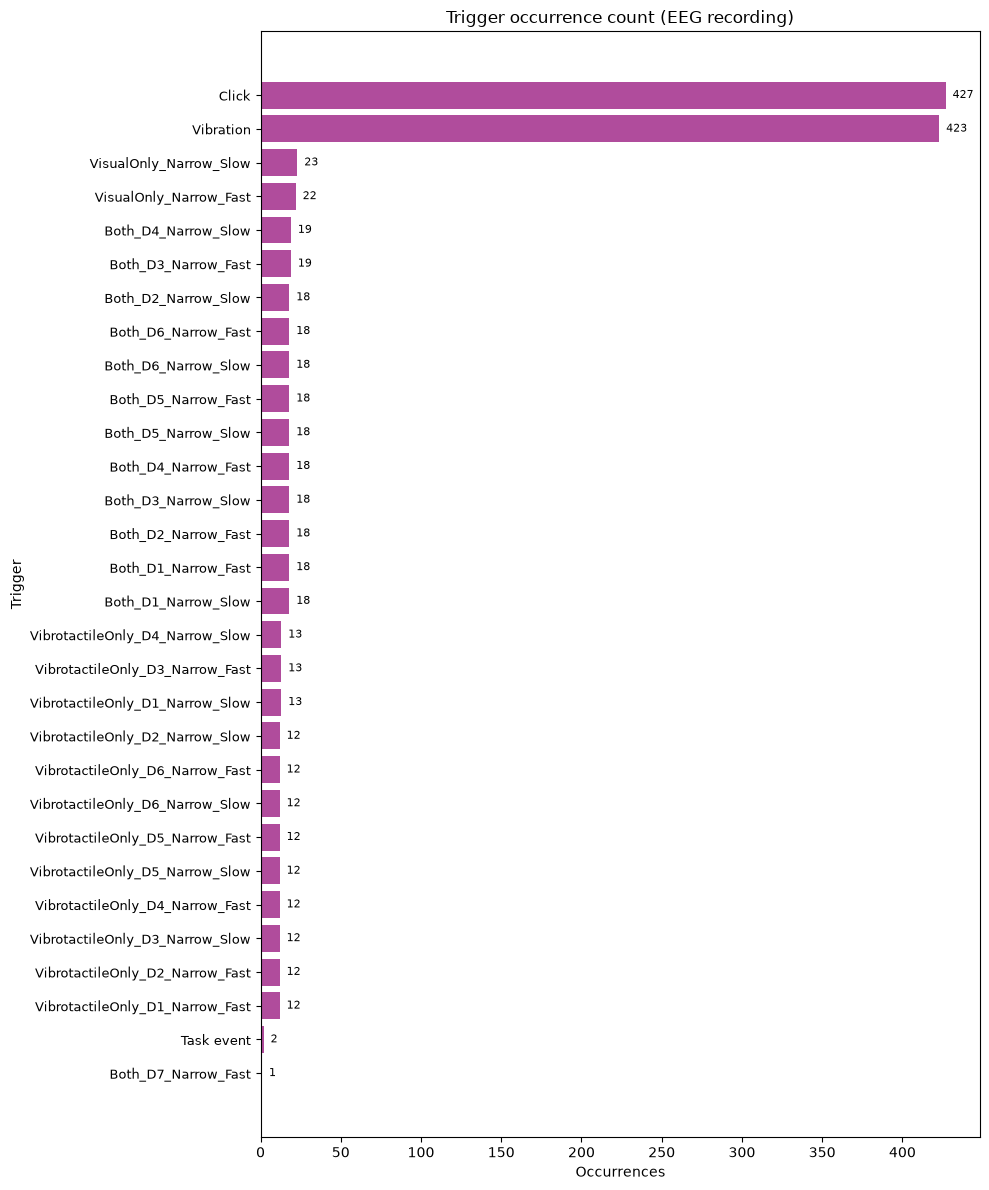

In [4]:
fig, counts = plot_trigger_counts(df_vmrk_markers, trigger_map, save_path=None, log_scale=False, title="Trigger occurrence count (EEG recording)")

### Triggers missmatch

In [5]:
mismatches_save_path = os.path.join(data_path, subjectID, 'Task1_PPS', 'Output', 'Triggers', 'trigger_mismatches_task1_' + subjectID + '.csv')
mismatches_df, alignment_df = compare_sequences(df_vmrk_markers, df_csv_markers, mismatches_save_path, trigger_map=trigger_map, normalize_map={127: 63})

if repair_d7:
    repaired_vmrk_save_path = os.path.join(data_path, subjectID, 'Task1_PPS', 'Output', 'Triggers', 'repaired_vmrk_triggers_task1_' + subjectID + '.csv')
    df_repaired_vmrk_markers = repair_vmrk_D7_triggers(vmrk2csv_save_path, mismatches_save_path, repaired_vmrk_save_path, trigger_map)

Found 64 mismatched markers
D7 triggers: [29, 30, 31, 32, 57, 58, 59, 60]
Missing D7 triggers to repair: 59
Saved repaired vmrk file:
/Users/floremunier/Library/CloudStorage/Dropbox-NeuroRestore/Flore Munier-Jolain/PercepPD/Data/Pilote001/Task1_PPS/Output/Triggers/repaired_vmrk_triggers_task1_Pilote001.csv


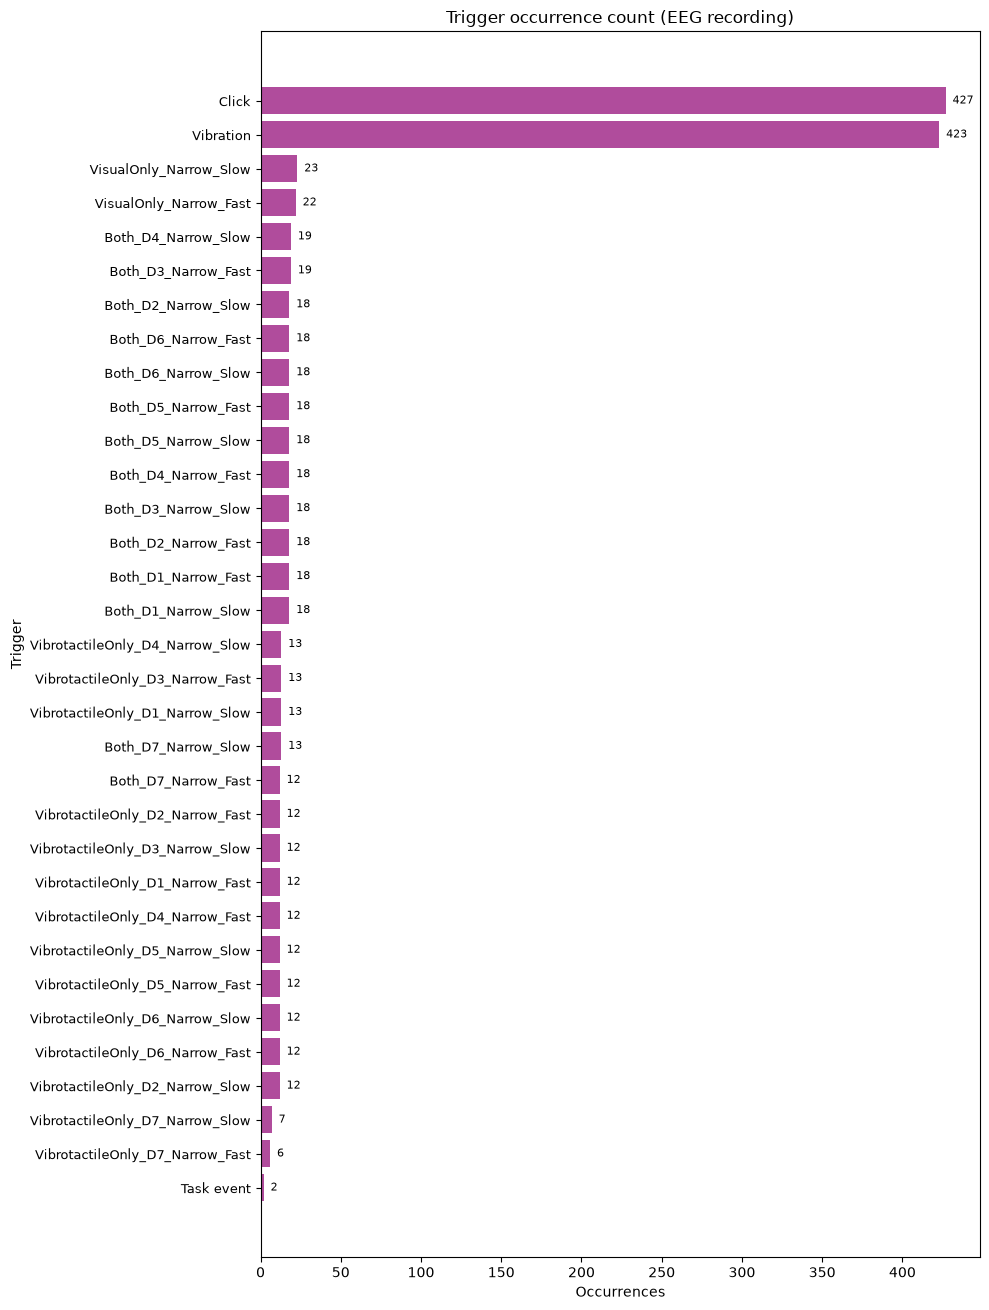

In [6]:
fig, counts = plot_trigger_counts(df_repaired_vmrk_markers, trigger_map, save_path=None, log_scale=False, title="Trigger occurrence count (EEG recording)")

# TASK 2 HIT OR MISS

### Load Data

In [7]:
# Extract .vmrk file path
vmrk2csv_save_path = os.path.join(data_path, subjectID, 'Task2_HitOrMiss', 'Output', 'Triggers', 'vmrk_triggers_task2_' + subjectID + '.csv')
vmrk_path =  extract_vmrk_path(data_path, subjectID, 'Task2_HitOrMiss')
df_vmrk_markers_t2 = load_vmrk(vmrk_path, vmrk2csv_save_path)

# Extrat trigger value from file
xlsx_path = os.path.join(os.path.dirname(data_path),'Code/EEG_analysis/Scripts/src/Trigger_Values.xlsx')
trigger_map_t2, _ = load_trigger_map(xlsx_path, sheet="Task2")

# Extrat csv log file with marker saved in unity
csv_path = vmrk_path =  os.path.join(data_path, subjectID, 'Task2_HitOrMiss', 'Raw', 'TaskData', csv_name2)
df_csv_markers_t2 = pd.read_csv(csv_path)
df_csv_markers_t2["TriggerValue"] = pd.to_numeric(df_csv_markers_t2["TriggerValue"], errors="coerce").astype("Int64")
df_csv_markers_t2 = df_csv_markers_t2.sort_values("Time").reset_index(drop=True)

Markers saved to: /Users/floremunier/Library/CloudStorage/Dropbox-NeuroRestore/Flore Munier-Jolain/PercepPD/Data/Pilote001/Task2_HitOrMiss/Output/Triggers/vmrk_triggers_task2_Pilote001.csv


### Remove practive trials

In [8]:
# Remove start/test triggers that are not useful for the analysis
phase_block_value = 25 # TO UPDATE with dictonary
df_vmrk_markers_t2 = keep_rows_after_starts(vmrk2csv_save_path, phase_block_value, vmrk2csv_save_path)

# MANUAL MODIF
df_vmrk_markers_t2.loc[df_vmrk_markers_t2["marker_num"] == 15, ["description", "trigger_value"]] = ["s7", 7]
df_vmrk_markers_t2.to_csv(vmrk2csv_save_path, index=False)

Markers saved to: /Users/floremunier/Library/CloudStorage/Dropbox-NeuroRestore/Flore Munier-Jolain/PercepPD/Data/Pilote001/Task2_HitOrMiss/Output/Triggers/vmrk_triggers_task2_Pilote001.csv


### EEG triggers count

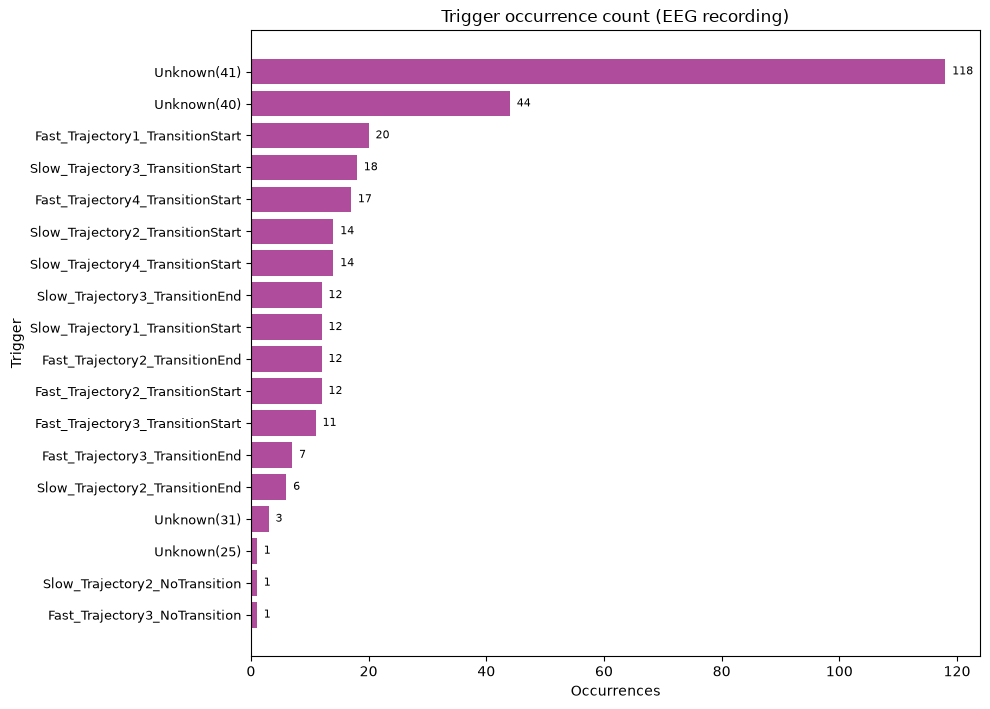

In [9]:
fig, counts = plot_trigger_counts(df_vmrk_markers_t2, trigger_map_t2, save_path=None, log_scale=False, title="Trigger occurrence count (EEG recording)")

### Triggers mismatches

In [11]:
mismatches_save_path_t2 = os.path.join(data_path, subjectID, 'Task2_HitOrMiss', 'Output', 'Triggers', 'trigger_mismatches_task2_' + subjectID + '.csv')
mismatches_df, alignment_df = compare_sequences(df_vmrk_markers_t2, df_csv_markers_t2, mismatches_save_path_t2, trigger_map=trigger_map, normalize_map=None)

Found 25 mismatched markers
